In [1]:
# Assignment: Text Classification Using IMDb Review Dataset

# ## Step 1: Data Loading
import pandas as pd
from sklearn.model_selection import train_test_split

# Load IMDb Movie Reviews dataset
dataset_path = './IMDB_Dataset.csv'  # 50,000 dataset split evenly
data = pd.read_csv(dataset_path)

# Inspect the dataset 
print(data.head())
print(data.info())
print(data.describe())
print(data.shape)



                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                   

In [2]:
# Split dataset into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [3]:
positive_count = test_data[test_data['sentiment'] == "positive"].shape[0]
positive_count

# how did it randomly select 50% +ve & -ve

5039

In [4]:
# ## Step 2: Data Preprocessing
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Moussa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Moussa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Moussa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
# Text cleaning function
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)
  
  # Apply text cleaning
data['cleaned_text'] = data['review'].apply(clean_text)

In [6]:
# ## Step 3: Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Bag of Words (BoW)
vectorizer_bow = CountVectorizer(max_features=5000)
bow_features = vectorizer_bow.fit_transform(data['cleaned_text'])

# TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=5000)
tfidf_features = vectorizer_tfidf.fit_transform(data['cleaned_text'])

# Word Embeddings
from gensim.models import Word2Vec

tokenized_reviews = [word_tokenize(text) for text in data['cleaned_text']]
word2vec_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1)

In [7]:
# Deep Learning Embeddings (BERT)
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

def extract_bert_features(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    outputs = bert_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()

bert_features = [extract_bert_features(text) for text in data['cleaned_text']]

In [8]:
# ## Step 4: Model Training
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Naive Bayes
nb_model = MultinomialNB()
bow_train, bow_test = train_test_split(bow_features, test_size=0.2, random_state=42)
nb_model.fit(bow_train, train_data['sentiment'])

MultinomialNB()

In [9]:
# Support Vector Machine
svm_model = SVC(class_weight='balanced', probability=True)
svm_model.fit(bow_train, train_data['sentiment'])

SVC(class_weight='balanced', probability=True)

In [15]:
# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(bow_train, train_data['sentiment'])


LogisticRegression(class_weight='balanced', max_iter=1000)

              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



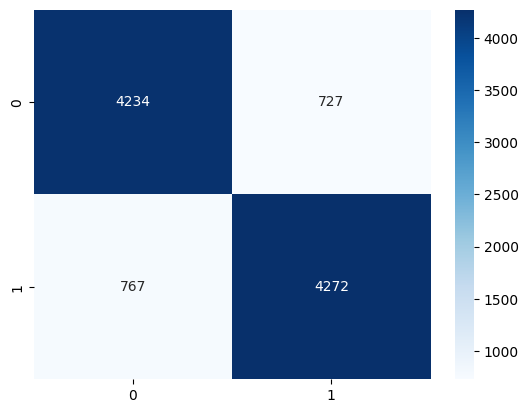

AUC-ROC: 0.9162576451151287
              precision    recall  f1-score   support

    negative       0.90      0.85      0.88      4961
    positive       0.86      0.91      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



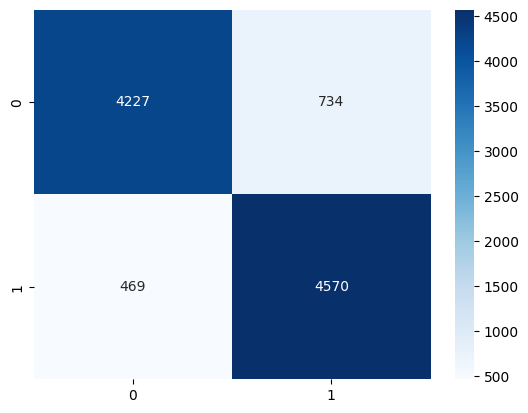

AUC-ROC: 0.9502261517590729
              precision    recall  f1-score   support

    negative       0.88      0.87      0.87      4961
    positive       0.87      0.88      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



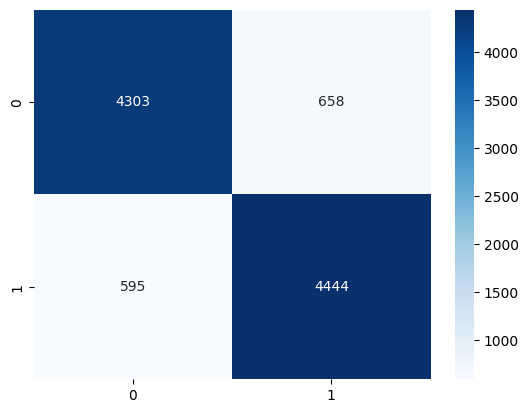

AUC-ROC: 0.9406561095177031


In [16]:
# ## Step 5: Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Function to evaluate model
def evaluate_model(model, test_features, test_labels):
    predictions = model.predict(test_features)
    print(classification_report(test_labels, predictions))
    cm = confusion_matrix(test_labels, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()
    print("AUC-ROC:", roc_auc_score(test_labels, model.predict_proba(test_features)[:, 1]))

# Evaluate models
evaluate_model(nb_model, bow_test, test_data['sentiment'])
evaluate_model(svm_model, bow_test, test_data['sentiment'])
evaluate_model(lr_model, bow_test, test_data['sentiment'])

In [17]:
# ## Step 6: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Example: Hyperparameter tuning for Logistic Regression
param_grid = {'C': [0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(class_weight='balanced'), param_grid, cv=5, scoring='f1')
grid_search.fit(bow_train, train_data['sentiment'])

print("Best Parameters:", grid_search.best_params_)

c:\Users\Moussa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Moussa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Moussa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y

Best Parameters: {'C': 0.1}


c:\Users\Moussa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
